<a href="https://colab.research.google.com/github/yang-song/score_sde_pytorch/blob/main/Score_SDE_demo_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation

1. `git clone https://github.com/yang-song/score_sde_pytorch.git`

2. Install [required packages](https://github.com/yang-song/score_sde_pytorch/blob/main/requirements.txt)

3. `cd` into folder `score_sde_pytorch`, launch a local jupyter server and connect to colab following [these instructions](https://research.google.com/colaboratory/local-runtimes.html)

4. Download pre-trained [checkpoints](https://drive.google.com/drive/folders/1tFmF_uh57O6lx9ggtZT_5LdonVK2cV-e?usp=sharing) and save them in the `exp` folder.

In [1]:
!CUDA_LAUNCH_BLOCKING=1

In [2]:
#@title Autoload all modules
#%load_ext autoreload
#%autoreload 2

from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import io
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import importlib
import os
import functools
import itertools
import torch
from losses import get_optimizer
from models.ema import ExponentialMovingAverage

import torch.nn as nn
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
#import tensorflow_gan as tfgan
import tqdm
import io
import likelihood
import controllable_generation
from utils import restore_checkpoint
sns.set(font_scale=2)
sns.set(style="whitegrid")

import models
from models import utils as mutils
from models import ncsnv2
from models import ncsnpp
from models import ddpm as ddpm_model
from models import layerspp
from models import layers
from models import normalization
import sampling
from likelihood import get_likelihood_fn
from sde_lib import VESDE, VPSDE, subVPSDE
from sampling import (ReverseDiffusionPredictor, 
                      LangevinCorrector, 
                      EulerMaruyamaPredictor, 
                      AncestralSamplingPredictor, 
                      NoneCorrector, 
                      NonePredictor,
                      AnnealedLangevinDynamics,
                      AnnealedLangevinDynamicsOld)

import datasets

/home/g4merz/.conda/envs/moconv/lib/python3.9/site-packages/torch/utils/cpp_extension.py:295: UserWarning: 

                               !! WARNING !!

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Your compiler (c++) is not compatible with the compiler Pytorch was
built with for this platform, which is g++ on linux. Please
use g++ to to compile your extension. Alternatively, you may
compile PyTorch from source using c++, and then you can also use
c++ to compile your extension.

See https://github.com/pytorch/pytorch/blob/master/CONTRIBUTING.md for help
with compiling PyTorch from source.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

                              !! WARNING !!

  warnings.warn(WRONG_COMPILER_WARNING.format(
/home/g4merz/.conda/envs/moconv/lib/python3.9/site-packages/torch/utils/cpp_extension.py:295: UserWarning: 

                               !! WARNING !!

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
    # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

1 Physical GPUs, 1 Logical GPUs


2025-08-25 22:56:01.621571: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13262 MB memory:  -> device: 0, name: Tesla V100-SXM2-16GB, pci bus id: 0004:04:00.0, compute capability: 7.0


In [4]:
from models import ncsnv2
#importlib.reload(models)
#importlib.reload(ncsnv2)
#from models import ncsnv2


In [12]:
# @title Load the score-based model
sde_str = 'VESDE' #@param ['VESDE', 'VPSDE', 'subVPSDE'] {"type": "string"}
if sde_str.lower() == 'vesde':
    from configs.ve import cifar10_ncsnpp_continuous as configs
    ckpt_filename = "exp/ve/cifar10_ncsnpp_continuous/checkpoint_24.pth"
    config = configs.get_config()  
    sde = VESDE(sigma_min=config.model.sigma_min, sigma_max=config.model.sigma_max, N=config.model.num_scales)
    sampling_eps = 1e-5

elif sde_str.lower() == 'vesde_old':
    from configs.ve.ncsnv2 import cifar10 as configs
    ckpt_filename = "ncsnv2/exp/logs/cifar10/best_checkpoint_with_denoising.pth"
    config = configs.get_config()  
    sde = VESDE(sigma_max=config.model.sigma_max, N=config.model.num_scales)
    sampling_eps = 1e-5
 
    
#elif sde.lower() == 'vpsde':
#    from configs.vp import cifar10_ddpmpp_continuous as configs  
#    ckpt_filename = "exp/vp/cifar10_ddpmpp_continuous/checkpoint_8.pth"
#    config = configs.get_config()
#    sde = VPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, N=config.model.num_scales)
#    sampling_eps = 1e-3
#elif sde.lower() == 'subvpsde':
#    from configs.subvp import cifar10_ddpmpp_continuous as configs
#    ckpt_filename = "exp/subvp/cifar10_ddpmpp_continuous/checkpoint_26.pth"
#    config = configs.get_config()
#    sde = subVPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, N=config.model.num_scales)
#    sampling_eps = 1e-3

batch_size =   36#@param {"type":"integer"}
config.training.batch_size = batch_size
config.eval.batch_size = batch_size

random_seed = 0 #@param {"type": "integer"}

sigmas = mutils.get_sigmas(config)
scaler = datasets.get_data_scaler(config)
inverse_scaler = datasets.get_data_inverse_scaler(config)

score_model = mutils.create_model(config)

optimizer = get_optimizer(config, score_model.parameters())
ema = ExponentialMovingAverage(score_model.parameters(),
                               decay=config.model.ema_rate)
state = dict(step=0, optimizer=optimizer,
             model=score_model, ema=ema)
if not sde_str.lower() == 'vesde_old':
    state = restore_checkpoint(ckpt_filename, state, config.device)
    ema.copy_to(score_model.parameters())

In [6]:
from models.ema import EMAHelper


In [11]:
states = torch.load(ckpt_filename, map_location=config.device)

score_model.load_state_dict(states[0], strict=True)
ema=True
if ema:
    ema_helper = EMAHelper(mu=config.model.ema_rate)
    ema_helper.register(score_model)
    ema_helper.load_state_dict(states[-1])
    ema_helper.ema(score_model)



KeyError: 0

In [13]:
#@title Visualization code

def image_grid(x):
    size = config.data.image_size
    channels = config.data.num_channels
    img = x.reshape(-1, size, size, channels)
    w = int(np.sqrt(img.shape[0]))
    img = img.reshape((w, w, size, size, channels)).transpose((0, 2, 1, 3, 4)).reshape((w * size, w * size, channels))
    return img

def show_samples(x):
    x = x.permute(0, 2, 3, 1).detach().cpu().numpy()
    img = image_grid(x)
    plt.figure(figsize=(8,8))
    plt.axis('off')
    plt.imshow(img)
    plt.show()

def show_samples_subplot(x,ax):
    x = x.permute(0, 2, 3, 1).detach().cpu().numpy()
    img = image_grid(x)
    ax.axis('off')
    ax.imshow(img)
    #plt.show()
    

# Predictor Corrector sampling


Recommended settings:

 | dataset | SDE | predictor | corrector | snr | n_steps |
|:----:|:----:|:----------:|:--------:|:---:|:----:|
|CIFAR-10 | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.16| 1|
|CIFAR-10 | VP | EulerMaruyamaPredictor | None | - | - |
|CIFAR-10 | subVP| EulerMaruyamaPredictor | None | - | - |
| LSUN/CelebA-HQ/FFHQ 256px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.075 | 1 |
| FFHQ 1024px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.15| 1 |

Check `probability_flow` to run PC sampling based on discretizing the probability flow ODE.

In [38]:


def get_sigmas(config):
  """Get sigmas --- the set of noise levels for SMLD from config files.
  Args:
    config: A ConfigDict object parsed from the config file
  Returns:
    sigmas: a jax numpy arrary of noise levels
  """
  sigmas = np.exp(
    np.linspace(np.log(config.model.sigma_max), np.log(config.model.sigma_min), config.model.num_scales))

  return sigmas



img_size = config.data.image_size
channels = config.data.num_channels
shape = (batch_size, channels, img_size, img_size)
x = sde.prior_sampling(shape).to(config.device)

sig = get_sigmas(config)
#print(score_model)
y=1
#print(sig)

eps = 1e-5
timesteps = torch.linspace(sde.T, eps, sde.N)
vec_t = torch.ones(shape[0], device=config.device) * timesteps[0]
print(vec_t)
#print(sigmas)

print(x.shape[0])
print(len(x.shape[1:]))
sigmas = torch.Tensor(sigmas)
#print(sigmas[0].view(36))

idx = 10
labels = torch.ones(1, device=x.device) * idx
labels = labels.long()
used_sigmas = sig[0]#.view(x.shape[0], *([1] * len(x.shape[1:])))

print(sde.marginal_prob(x,vec_t)[1])
print(used_sigmas)


tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
36
3
tensor([50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000,
        50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000,
        50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000,
        50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000, 50.0000,
        50.0000, 50.0000, 50.0000, 50.0000], device='cuda:0')
49.99999999999999


In [56]:
eps = 1e-5
timesteps = torch.linspace(sde.T, eps, sde.N)
device='cuda'
vec_t = torch.ones(shape[0], device=config.device) * timesteps[-1]
#print(vec_t)
with torch.no_grad():
    # Initial sample
    x = sde.prior_sampling(shape).to(device)
    timesteps = torch.linspace(sde.T, eps, sde.N, device=device)

    for i in range(sde.N):
        t = timesteps[i]

        labels = torch.ones(shape[0], device=device) * i
        #labels = labels.long()
        #labels = i
        vec_t = torch.ones(shape[0], device=t.device) * t
        
        
labels = torch.round(labels).long()


alpha = torch.ones_like(labels)
eps=1e-3

print(vec_t)
#print(timesteps)

timesteps = torch.linspace(sde.T, eps, sde.N, device=t.device)

t = vec_t
labels = sde.T - t
labels *= sde.N - 1
labels = torch.round(labels).long()

print(labels)
with torch.no_grad():

    y=score_model(x,labels)
vec_t = torch.ones(shape[0], device=config.device) * timesteps[-1]

std = sde.marginal_prob(x, vec_t)[1]
print(std)
#print(labels)


tensor([1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05],
       device='cuda:0')
tensor([231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231,
        231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231, 231,
        231, 231, 231, 231, 231, 231, 231, 231], device='cuda:0')
tensor([0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101,
        0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101,
        0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101,
        0.0101, 0.0101, 0.0101, 0

In [10]:
sig = get_sigmas(config)
sig = torch.Tensor(sig).cuda()

used_sigmas = sig[labels].view(x.shape[0], *([1] * len(x.shape[1:])))
print(used_sigmas.shape)

torch.Size([36, 1, 1, 1])


In [57]:
import importlib
importlib.reload(sampling)
from sampling import (ReverseDiffusionPredictor, 
                      LangevinCorrector, 
                      EulerMaruyamaPredictor, 
                      AncestralSamplingPredictor, 
                      NoneCorrector, 
                      NonePredictor,
                      AnnealedLangevinDynamics,
                      AnnealedLangevinDynamicsOld)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


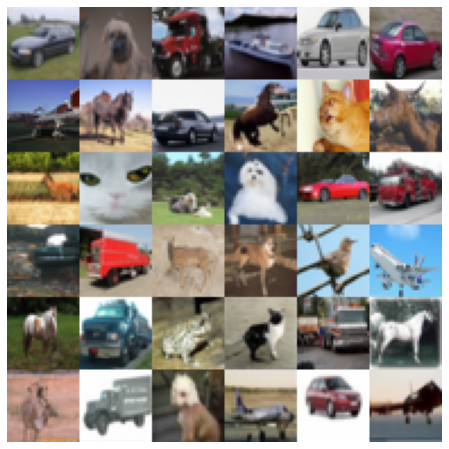

CPU times: user 2min 5s, sys: 21.8 s, total: 2min 27s
Wall time: 2min 26s


In [10]:
%%time
#@title PC sampling
img_size = config.data.image_size
channels = config.data.num_channels
shape = (batch_size, channels, img_size, img_size)
predictor = ReverseDiffusionPredictor #@param ["EulerMaruyamaPredictor", "AncestralSamplingPredictor", "ReverseDiffusionPredictor", "None"] {"type": "raw"}
corrector = LangevinCorrector #@param ["LangevinCorrector", "AnnealedLangevinDynamics", "None"] {"type": "raw"}
snr = 0.16 #@param {"type": "number"}
n_steps =  1 #@param {"type": "integer"}
probability_flow = False #@param {"type": "boolean"}
sampling_fn = sampling.get_pc_sampler(sde, shape, predictor, corrector,
                                      inverse_scaler, snr, n_steps=n_steps,
                                      probability_flow=probability_flow,
                                      continuous=config.training.continuous,
                                      eps=sampling_eps, device=config.device)

#sampling_fn = sampling.get_old_pc_sampler(sde, shape, predictor, corrector,
#                                      inverse_scaler, snr, n_steps=n_steps,
#                                      probability_flow=probability_flow,
#                                      continuous=config.training.continuous,
#                                      eps=sampling_eps, device=config.device)


x, n = sampling_fn(score_model)
show_samples(x)

# Probability flow ODE

With black-box ODE solvers, we can produce samples, compute likelihoods, and obtain a uniquely identifiable encoding of any data point.

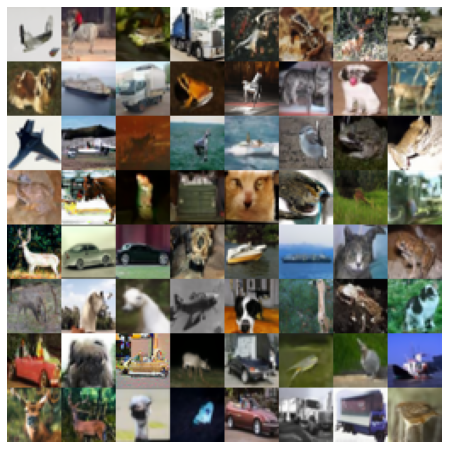

In [ ]:
 #@title ODE sampling

shape = (batch_size, 3, 32, 32)
sampling_fn = sampling.get_ode_sampler(sde,                                        
                                       shape, 
                                       inverse_scaler,                                       
                                       denoise=True, 
                                       eps=sampling_eps,
                                       device=config.device)
x, nfe = sampling_fn(score_model)
show_samples(x)

In [ ]:
#@title Likelihood computation
train_ds, eval_ds, _ = datasets.get_dataset(config, uniform_dequantization=True, evaluation=True)
eval_iter = iter(eval_ds)
bpds = []
likelihood_fn = likelihood.get_likelihood_fn(sde,                                              
                                             inverse_scaler,                                             
                                             eps=1e-5)
for batch in eval_iter:
  img = batch['image']._numpy()
  img = torch.tensor(img).permute(0, 3, 1, 2).to(config.device)
  img = scaler(img)
  bpd, z, nfe = likelihood_fn(score_model, img)
  bpds.extend(bpd)
  print(f"average bpd: {torch.tensor(bpds).mean().item()}, NFE: {nfe}")

RuntimeError: CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 15.00 GiB total capacity; 2.49 GiB already allocated; 28.38 MiB free; 2.59 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

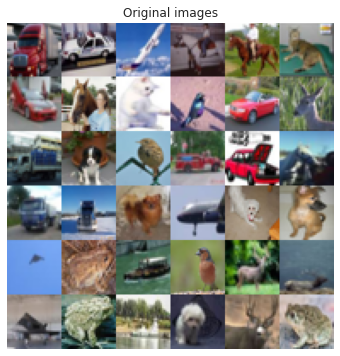

In [10]:
#@title Representations
train_ds, eval_ds, _ = datasets.get_dataset(config, uniform_dequantization=False, evaluation=True)
eval_batch = next(iter(eval_ds))
eval_images = eval_batch['image']._numpy()
shape = (batch_size, 3, 32, 32)

likelihood_fn = likelihood.get_likelihood_fn(sde, inverse_scaler, eps=1e-5)
sampling_fn = sampling.get_ode_sampler(sde, shape, inverse_scaler,
                                       denoise=True, eps=sampling_eps, device=config.device)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(image_grid(eval_images))
plt.title('Original images')

eval_images = torch.from_numpy(eval_images).permute(0, 3, 1, 2).to(config.device)
_, latent_z, _ = likelihood_fn(score_model, scaler(eval_images))

x, nfe = sampling_fn(score_model, latent_z)

x = x.permute(0, 2, 3, 1).cpu().numpy()
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(image_grid(x))
plt.title('Reconstructed images')

# Controllable generation

Several demonstrations on how to solve inverse problems with our SDE framework.

Recommended settings

| dataset | SDE | predictor | corrector | snr | n_steps |
|:----:|:----:|:----------:|:--------:|:---:|:----:|
|CIFAR-10 | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.16| 1|
|CIFAR-10 | VP | EulerMaruyamaPredictor | None | - | - |
|CIFAR-10 | subVP| EulerMaruyamaPredictor | None | - | - |
| LSUN/CelebA-HQ/FFHQ 256px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.075 | 1 |
| FFHQ 1024px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.15| 1 |

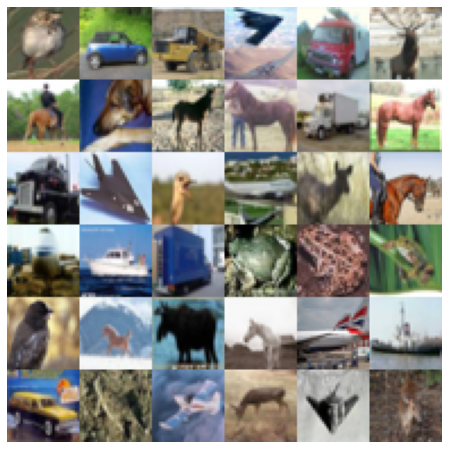

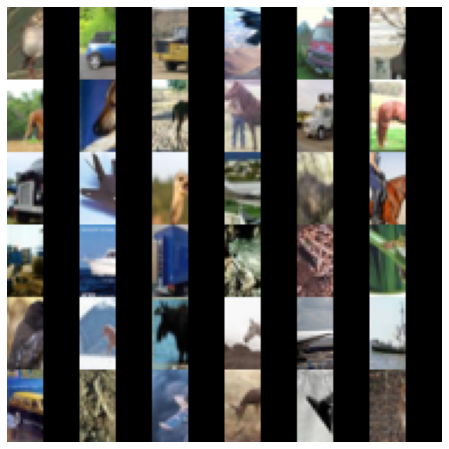

KeyboardInterrupt: 

In [8]:
%%time

#@title PC inpainting

train_ds, eval_ds, _ = datasets.get_dataset(config)
eval_iter = iter(eval_ds)
bpds = []

predictor = ReverseDiffusionPredictor #@param ["EulerMaruyamaPredictor", "AncestralSamplingPredictor", "ReverseDiffusionPredictor", "None"] {"type": "raw"}
corrector = LangevinCorrector #@param ["LangevinCorrector", "AnnealedLangevinDynamics", "None"] {"type": "raw"}
snr = 0.16 #@param {"type": "number"}
n_steps = 1 #@param {"type": "integer"}
probability_flow = False #@param {"type": "boolean"}

pc_inpainter = controllable_generation.get_pc_inpainter(sde,
                                                        predictor, corrector,
                                                        inverse_scaler,
                                                        snr=snr,
                                                        n_steps=n_steps,
                                                        probability_flow=probability_flow,
                                                        continuous=config.training.continuous,
                                                        denoise=True)

batch = next(eval_iter)
img = batch['image']._numpy()
img = torch.from_numpy(img).permute(0, 3, 1, 2).to(config.device)
show_samples(img)

mask = torch.ones_like(img)
mask[:, :, :, 16:] = 0.
show_samples(img * mask)


x = pc_inpainter(score_model, scaler(img), mask)
show_samples(x)

In [ ]:
#@title PC colorizer
train_ds, eval_ds, _ = datasets.get_dataset(config)
eval_iter = iter(eval_ds)
bpds = []

predictor = ReverseDiffusionPredictor #@param ["EulerMaruyamaPredictor", "AncestralSamplingPredictor", "ReverseDiffusionPredictor", "None"] {"type": "raw"}
corrector = LangevinCorrector #@param ["LangevinCorrector", "AnnealedLangevinDynamics", "None"] {"type": "raw"}
#corrector = AnnealedLangevinDynamics
snr = 0.16 #@param {"type": "number"}
n_steps = 1 #@param {"type": "integer"}
probability_flow = False #@param {"type": "boolean"}

batch = next(eval_iter)
img = batch['image']._numpy()
img = torch.from_numpy(img).permute(0, 3, 1, 2).to(config.device)
show_samples(img)
gray_scale_img = torch.mean(img, dim=1, keepdims=True).repeat(1, 3, 1, 1)
show_samples(gray_scale_img)
gray_scale_img = scaler(gray_scale_img)
pc_colorizer = controllable_generation.get_pc_colorizer(
    sde, predictor, corrector, inverse_scaler,
    snr=snr, n_steps=n_steps, probability_flow=probability_flow,
    continuous=config.training.continuous, denoise=True
)
x = pc_colorizer(score_model, gray_scale_img)

show_samples(x)

## Source separation

In [16]:
import importlib
import sampling
importlib.reload(sampling)
from sampling import (ReverseDiffusionPredictor, 
                      LangevinCorrector, 
                      EulerMaruyamaPredictor, 
                      AncestralSamplingPredictor, 
                      NoneCorrector, 
                      NonePredictor,
                      AnnealedLangevinDynamics)
#import controllable_generation_copy


In [14]:
print(sde.N)

1000


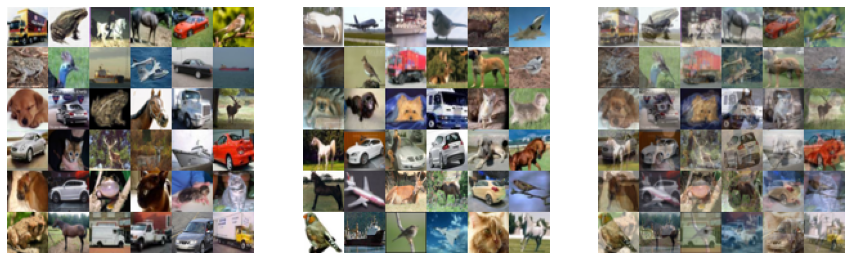

In [17]:

#@title PC colorizer
train_ds, eval_ds, _ = datasets.get_dataset(config)
eval_iter = iter(eval_ds)
bpds = []

predictor = ReverseDiffusionPredictor #@param ["EulerMaruyamaPredictor", "AncestralSamplingPredictor", "ReverseDiffusionPredictor", "None"] {"type": "raw"}
corrector = AnnealedLangevinDynamics #@param ["LangevinCorrector", "AnnealedLangevinDynamics", "None"] {"type": "raw"}
#snr = 0.16 #@param {"type": "number"}
snr = 0.4
n_steps = 1 #@param {"type": "integer"}
probability_flow = False #@param {"type": "boolean"}

batch1 = next(eval_iter)
img1 = batch1['image']._numpy()
img1 = torch.from_numpy(img1).permute(0, 3, 1, 2).to(config.device)

batch2 = next(eval_iter)
img2 = batch2['image']._numpy()
img2 = torch.from_numpy(img2).permute(0, 3, 1, 2).to(config.device)


mixed = torch.Tensor(sum([img1.cpu(),img2.cpu()])).cuda().view(batch_size, 3, 32, 32)

fig,ax = plt.subplots(1,3,figsize=(15,5))
show_samples_subplot(img1,ax[0])
show_samples_subplot(img2,ax[1])
show_samples_subplot(mixed/2,ax[2])



#gray_scale_img = torch.mean(img, dim=1, keepdims=True).repeat(1, 3, 1, 1)
#show_samples(gray_scale_img)
#gray_scale_img = scaler(gray_scale_img)
#pc_colorizer = controllable_generation.get_pc_colorizer(
#    sde, predictor, corrector, inverse_scaler,
#    snr=snr, n_steps=n_steps, probability_flow=probability_flow,
#    continuous=config.training.continuous, denoise=True
#)
#x = pc_colorizer(score_model, gray_scale_img)

#show_samples(x)

In [151]:
import importlib
import controllable_generation_copy
importlib.reload(controllable_generation_copy)
import controllable_generation_copy

In [152]:
snr=0.3

In [153]:
#M=20, every 10th noise scale, autograd loss seems ok

In [18]:
%%time
mixed_scale_img = scaler(mixed)
pc_separator = controllable_generation.get_mixture_conditional_sampler(
    sde, predictor, corrector, inverse_scaler,
    snr=snr, n_steps=1, probability_flow=probability_flow,
    continuous=config.training.continuous, denoise=True,M=100
)
x1,x2 = pc_separator(score_model, mixed_scale_img)

#show_samples(x)

CPU times: user 2min 5s, sys: 16.2 s, total: 2min 21s
Wall time: 2min 22s


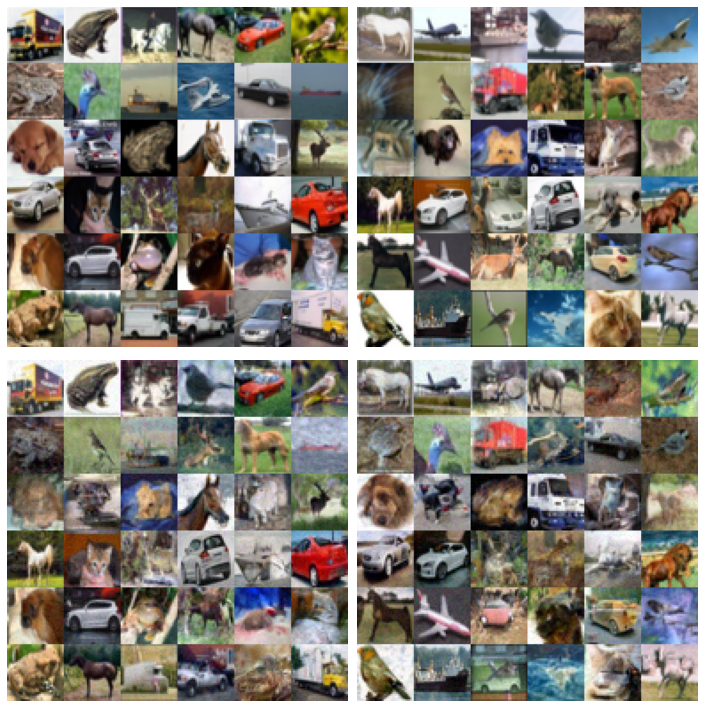

In [19]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(x1,ax[1][0])
show_samples_subplot(x2,ax[1][1])
plt.tight_layout()

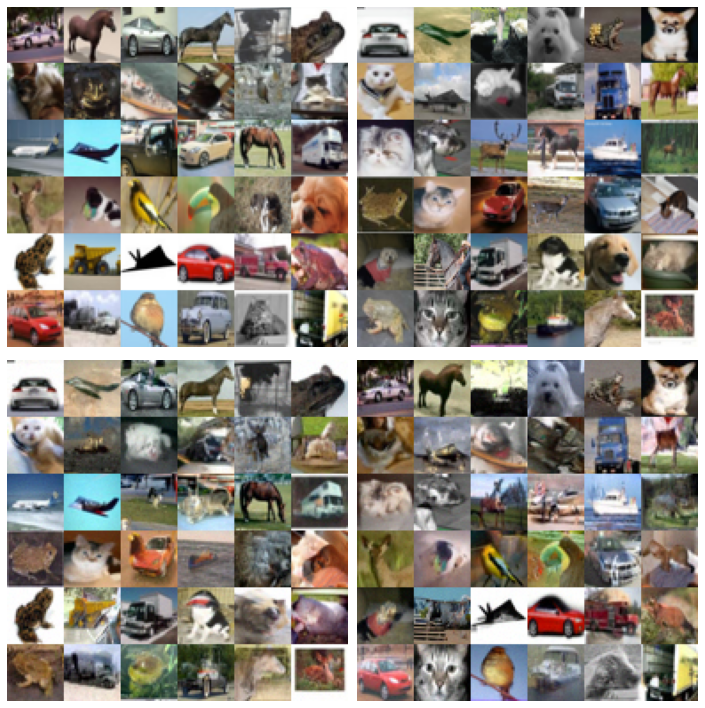

In [70]:
# M=100, every 20th scale
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(x1,ax[1][0])
show_samples_subplot(x2,ax[1][1])
plt.tight_layout()

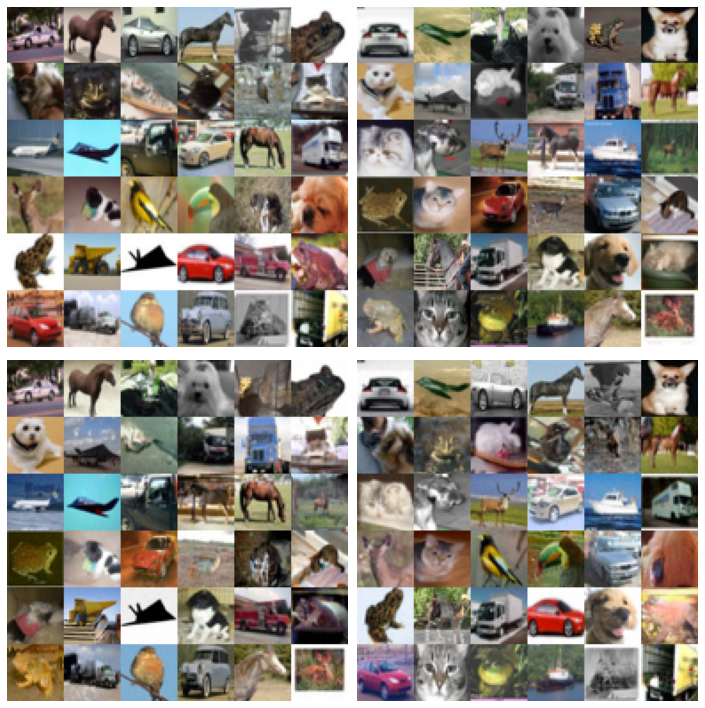

In [62]:
#M=100, every 10th scale
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(x1,ax[1][0])
show_samples_subplot(x2,ax[1][1])
plt.tight_layout()

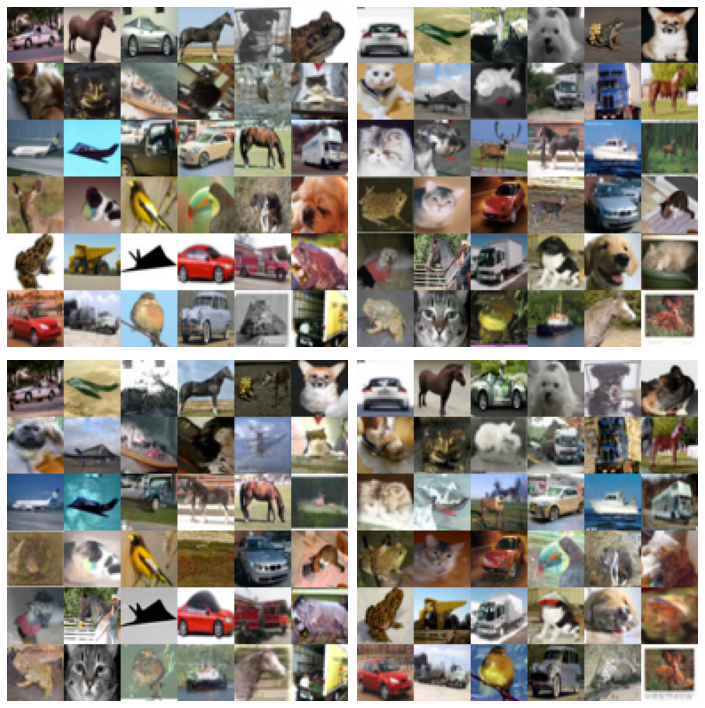

In [60]:
#M=50, every 10th scale
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(x1,ax[1][0])
show_samples_subplot(x2,ax[1][1])
plt.tight_layout()

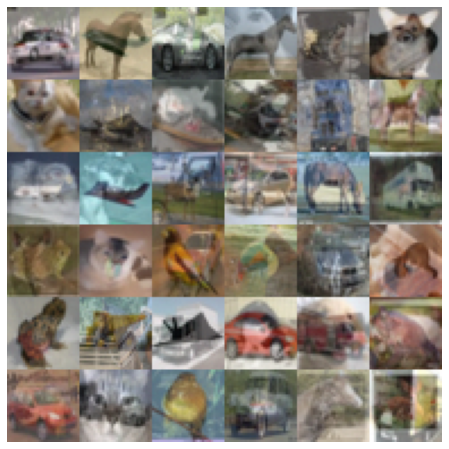

In [56]:
show_samples((x1+x2)/2)

In [36]:
score_fn = mutils.get_score_fn(sde, score_model, train=False,
                                   continuous=True)
eps = 1e-5

timesteps = torch.linspace(sde.T, eps, sde.N)

tsn = []
for i,ts in enumerate(timesteps[0::10]):
    tsn.append(ts)

In [37]:
print(len(tsn))
print(timesteps[999])
print(tsn)

100
tensor(1.0000e-05)
[tensor(1.), tensor(0.9900), tensor(0.9800), tensor(0.9700), tensor(0.9600), tensor(0.9500), tensor(0.9399), tensor(0.9299), tensor(0.9199), tensor(0.9099), tensor(0.8999), tensor(0.8899), tensor(0.8799), tensor(0.8699), tensor(0.8599), tensor(0.8499), tensor(0.8398), tensor(0.8298), tensor(0.8198), tensor(0.8098), tensor(0.7998), tensor(0.7898), tensor(0.7798), tensor(0.7698), tensor(0.7598), tensor(0.7498), tensor(0.7397), tensor(0.7297), tensor(0.7197), tensor(0.7097), tensor(0.6997), tensor(0.6897), tensor(0.6797), tensor(0.6697), tensor(0.6597), tensor(0.6497), tensor(0.6396), tensor(0.6296), tensor(0.6196), tensor(0.6096), tensor(0.5996), tensor(0.5896), tensor(0.5796), tensor(0.5696), tensor(0.5596), tensor(0.5496), tensor(0.5395), tensor(0.5295), tensor(0.5195), tensor(0.5095), tensor(0.4995), tensor(0.4895), tensor(0.4795), tensor(0.4695), tensor(0.4595), tensor(0.4495), tensor(0.4394), tensor(0.4294), tensor(0.4194), tensor(0.4094), tensor(0.3994), tens

In [17]:
%%time
xtest = score_fn(img1,vec_t)



CPU times: user 35.7 ms, sys: 66.4 ms, total: 102 ms
Wall time: 113 ms


In [14]:
score_fn = mutils.get_score_fn(sde, score_model, train=False,
                               continuous=False)
eps = 1e-5
timesteps = torch.linspace(sde.T, eps, sde.N)
vec_t = torch.ones(img1.shape[0], device=img1.device) * timesteps[1]

ve_noise_scale = sde.marginal_prob(img1, vec_t)[1]
x1 = sde.prior_sampling(mixed.shape).to(mixed.device)
x2 = sde.prior_sampling(mixed.shape).to(mixed.device)
print(x1.shape)

s = score_fn(x1, vec_t)
lambda_ = 1./ve_noise_scale**2
print(x1.max())

torch.Size([36, 3, 32, 32])
tensor(229.4053, device='cuda:0')


In [47]:
999/27

37.0

In [133]:
print(timesteps[-1])
print(timesteps[10])
print(timesteps[0::111])
print(timesteps[-100])
vec_t = torch.ones(img1.shape[0], device=img1.device) * timesteps[-1]

ve_noise_scale = sde.marginal_prob(img1, vec_t)[1]
print(ve_noise_scale)

np.sqrt(2e-5/(ve_noise_scale[0].cpu()**2))/2

tensor(1.0000e-05)
tensor(0.9900)
tensor([1.0000e+00, 8.8889e-01, 7.7778e-01, 6.6667e-01, 5.5556e-01, 4.4445e-01,
        3.3334e-01, 2.2223e-01, 1.1112e-01, 1.0000e-05])
tensor(0.0991)
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100],
       device='cuda:0')


tensor(0.2236)

In [89]:
x1n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
x2n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
xs=[x1n,x2n]
recon_loss = (torch.norm(torch.flatten(sum(xs) - mixed)) ** 2)
recon_grads = torch.autograd.grad(recon_loss, xs)
print(recon_grads[0].shape)

torch.Size([4, 3, 32, 32])


In [48]:
def mixture_grad_fn(x1, x2, mixed):

    x1n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
    x2n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
    recon_loss = (torch.norm(torch.flatten(sum(x1n,x2n) - mixed, start_dim=1),dim=1) ** 2).requires_grad_(True)
    print(recon_loss)
    rl1 = torch.stack([torch.autograd.grad(recon_loss[i], x1n, create_graph=True)[0][i] for i in range(len(recon_loss))])

    
    
    #x1n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
    #x2n = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
    #xs = [x1,x2]
    #recon_loss = torch.norm(torch.flatten(sum(x1n,x2n) - mixed, start_dim=1),dim=1) ** 2
    #print(recon_loss)
    #rl1 = torch.stack([torch.autograd.grad(recon_loss[i], x1n, create_graph=True)[0][i] for i in range(len(recon_loss))])
    #rl2 = torch.stack([torch.autograd.grad(recon_loss[i], x2n, create_graph=True)[0][i] for i in range(len(recon_loss))])


    return rl1


x1 = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
x2 = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
r1 = mixture_grad_fn(x1,x2,mixed)


tensor([1.2927e+08, 1.2920e+08, 1.2945e+08, 1.2911e+08, 1.3003e+08, 1.3008e+08,
        1.3010e+08, 1.2856e+08, 1.3062e+08, 1.3133e+08, 1.2978e+08, 1.2896e+08,
        1.3025e+08, 1.2923e+08, 1.2779e+08, 1.3030e+08], device='cuda:0',
       grad_fn=<PowBackward0>)


In [54]:

x1 = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
x2 = nn.Parameter(sde.prior_sampling(mixed.shape).to(mixed.device))
xs = [x1,x2]
s = sum(x1,x2)
print(s)
recon_loss = torch.norm(torch.flatten(sum(x1,x2) - mixed, start_dim=1),dim=1) ** 2
#print(recon_loss)
rl1 = torch.stack([torch.autograd.grad(recon_loss[i], x1, create_graph=True)[0][i] for i in range(len(recon_loss))])
rl2 = torch.stack([torch.autograd.grad(recon_loss[i], x2, create_graph=True)[0][i] for i in range(len(recon_loss))])


tensor([[[[-1.7465e+02, -6.4530e+01,  1.5829e+02,  ..., -2.0157e+02,
           -1.7192e+02, -3.2031e+02],
          [-8.3048e+01,  3.7539e+01, -3.5888e+01,  ...,  3.9475e+01,
           -4.5795e+02,  1.9658e+02],
          [-9.8867e+01,  7.2086e+01,  2.7452e+02,  ...,  2.8038e+02,
           -1.6192e+02,  2.6635e+02],
          ...,
          [-1.1265e+02,  4.2734e+01, -3.4829e+01,  ...,  8.0140e+01,
           -3.4312e+02,  6.6905e+01],
          [ 1.9209e+02, -2.1130e+01, -3.6494e+01,  ..., -2.3797e+02,
            5.2046e+02,  1.0056e+02],
          [ 9.3709e+01,  7.5983e+01, -6.3885e+00,  ..., -2.5557e+02,
            3.8772e+02,  8.8843e+01]],

         [[-1.6415e+01,  9.9234e+01,  6.9776e+01,  ...,  2.4306e+02,
           -1.1676e+02, -7.5491e+01],
          [-2.0659e+02,  4.4982e+02,  1.2312e+01,  ..., -8.7644e+01,
           -1.1962e+02,  3.3067e+02],
          [-2.5852e+02,  7.7803e+01, -4.1470e+01,  ..., -4.5618e+02,
            1.1494e+02, -7.8630e+01],
          ...,
     

In [18]:
#l0 = recon_loss[0]#.clone().detach().requires_grad_(True)
#rl = torch.autograd.grad(l0, x1, create_graph=True,allow_unused=True)[0]
#print(rl)


#recon_grads_x1 = torch.stack([torch.autograd.grad(l, x1, create_graph=True)[0] for l in recon_loss])
#print(recon_grads_x1.shape)
print(rl[0][0][0])

torch.Size([16, 3, 32, 32])
tensor([-268.1992, -131.8745,  130.4951, -471.4932, -177.5420, -459.7276,
         655.6639, -172.5057,   89.3670, -311.5877, -774.7383,  -72.8069,
         198.3129,   22.3207,   24.5911,  189.9311,  -71.4083, -584.8894,
        -126.8100, -624.6985, -964.3461, -215.5338,  556.8370, -374.3990,
        -227.4248,  -73.6217, -484.9417, -146.0145, -142.8013, -682.1181,
        -331.5395, -296.4458], device='cuda:0', grad_fn=<SelectBackward0>)


In [14]:
rl1.shape

torch.Size([16, 3, 32, 32])

In [15]:
#Old way
#x1 = nn.Parameter(sde.prior_sampling(mixed.shape)[0].to(mixed.device))
#x2 = nn.Parameter(sde.prior_sampling(mixed.shape)[0].to(mixed.device))
i = 0
xs = [x1[i].clone().detach().requires_grad_(True),x2[i].clone().detach().requires_grad_(True)]
recon_loss = (torch.norm(torch.flatten(sum(x1[i],x2[i]) - mixed[i])) ** 2).requires_grad_(True)
print(recon_loss)
recon_grads = torch.autograd.grad(recon_loss, xs)
print(recon_grads[i][0][0])

tensor(30522318., device='cuda:0', grad_fn=<PowBackward0>)


RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

In [47]:
xs = torch.Tensor(sum([img1.cpu(),img2.cpu()])).cuda().view(batch_size, 3, 32, 32)

s = xs-mixed
print(mixed[0])

tensor([[[1.0196, 0.9569, 0.9765,  ..., 1.6431, 1.6706, 1.6902],
         [1.0392, 1.0039, 1.0196,  ..., 1.5922, 1.5922, 1.5961],
         [1.0667, 1.0431, 1.0745,  ..., 1.5451, 1.5294, 1.5137],
         ...,
         [1.5843, 1.5529, 1.4392,  ..., 1.3961, 1.7294, 1.8235],
         [1.6000, 1.5059, 1.4314,  ..., 1.5255, 1.7569, 1.8471],
         [1.6000, 1.4000, 1.3569,  ..., 1.8000, 1.8275, 1.8431]],

        [[1.0549, 1.0039, 1.0157,  ..., 1.6549, 1.6902, 1.7176],
         [1.0863, 1.0706, 1.0745,  ..., 1.6000, 1.6078, 1.6235],
         [1.1294, 1.1176, 1.1373,  ..., 1.5529, 1.5451, 1.5412],
         ...,
         [1.6275, 1.5804, 1.4431,  ..., 1.3608, 1.7098, 1.8235],
         [1.6392, 1.5255, 1.4314,  ..., 1.4980, 1.7373, 1.8392],
         [1.6392, 1.4157, 1.3529,  ..., 1.7843, 1.8196, 1.8392]],

        [[1.0902, 1.0353, 1.0549,  ..., 1.6510, 1.6824, 1.7059],
         [1.1176, 1.0941, 1.1059,  ..., 1.5961, 1.6039, 1.6118],
         [1.1608, 1.1373, 1.1647,  ..., 1.5490, 1.5412, 1.

In [98]:
print(xs[0])

tensor([[[0.9529, 0.8784, 0.8353,  ..., 0.7529, 0.7490, 0.7569],
         [1.0078, 1.0392, 1.0392,  ..., 0.7686, 0.7765, 0.7765],
         [0.9725, 1.0588, 1.0627,  ..., 0.8157, 0.8118, 0.8118],
         ...,
         [0.6706, 0.6784, 0.6784,  ..., 0.8078, 0.8275, 0.8157],
         [0.8157, 0.8392, 0.8627,  ..., 0.7255, 0.7490, 0.7569],
         [0.8235, 0.8157, 0.8196,  ..., 0.6863, 0.7020, 0.7608]],

        [[1.3059, 1.2588, 1.2431,  ..., 1.2471, 1.2392, 1.2431],
         [1.3255, 1.3216, 1.3294,  ..., 1.2706, 1.2627, 1.2667],
         [1.3216, 1.3529, 1.3529,  ..., 1.2902, 1.2667, 1.2784],
         ...,
         [0.9216, 0.9333, 0.9529,  ..., 1.0627, 1.0784, 1.0549],
         [1.0627, 1.0902, 1.1255,  ..., 1.0431, 1.0510, 1.0235],
         [1.0627, 1.0627, 1.0706,  ..., 1.0157, 1.0157, 1.0353]],

        [[1.6627, 1.6392, 1.6510,  ..., 1.6824, 1.6863, 1.6863],
         [1.6314, 1.6588, 1.6941,  ..., 1.6980, 1.6980, 1.6980],
         [1.6431, 1.7020, 1.7216,  ..., 1.6863, 1.6745, 1.

## Class-conditional generation



Check out the [class-conditional generation section](https://colab.research.google.com/drive/1dRR_0gNRmfLtPavX2APzUggBuXyjWW55#scrollTo=HiYRNB-Wk329&line=3&uniqifier=1) in our [JAX demo](https://colab.research.google.com/drive/1dRR_0gNRmfLtPavX2APzUggBuXyjWW55?usp=sharing)